<a href="https://colab.research.google.com/github/Chu1x/TPLLMs_Lab-3-GPT/blob/main/poetry_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Where Hidden Rhythms in Silent Vectors Lie
## A Character-Level GPT for Poetry Generation

**Run cells in order. GPU is required — make sure Runtime > Change runtime type > T4 GPU is selected.**

Stages:
1. Corpus collection
2. Model implementation
3. Training + monitoring
4. Hyperparameter experiments
5. Analysis of generated poems

---
## 0. Setup & Imports

In [2]:
import os, math, time, re, random, urllib.request
from collections import Counter
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## 1. Corpus Collection

We download English poetry from Project Gutenberg (public domain):
- Shakespeare's Sonnets
- Keats: Complete Poems
- Shelley: Complete Poems
- Byron: Selected poems
- Wordsworth, Blake, Tennyson

Target: ~5–8 MB of clean poetry text.

In [2]:
# Project Gutenberg URLs for public-domain English poetry
GUTENBERG_URLS = {
    'shakespeare_sonnets':  'https://www.gutenberg.org/cache/epub/1041/pg1041.txt',
    'keats':                'https://www.gutenberg.org/cache/epub/23/pg23.txt',
    'shelley':              'https://www.gutenberg.org/cache/epub/4800/pg4800.txt',
    'byron':                'https://www.gutenberg.org/cache/epub/20158/pg20158.txt',
    'blake':                'https://www.gutenberg.org/cache/epub/574/pg574.txt',
    'tennyson':             'https://www.gutenberg.org/cache/epub/599/pg599.txt',
    'wordsworth':           'https://www.gutenberg.org/cache/epub/9622/pg9622.txt',
    'spenser':              'https://www.gutenberg.org/cache/epub/1022/pg1022.txt',
    'milton_paradise_lost': 'https://www.gutenberg.org/cache/epub/20/pg20.txt',
    'poe':                  'https://www.gutenberg.org/cache/epub/10031/pg10031.txt',
}

def fetch_gutenberg(url: str) -> str:
    """Download a Project Gutenberg text and strip the header/footer boilerplate."""
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=30) as resp:
            raw = resp.read().decode('utf-8', errors='ignore')
    except Exception as e:
        print(f'  WARNING: failed to fetch {url}: {e}')
        return ''

    # Strip Gutenberg header (everything before *** START ***)
    start_markers = ['*** START OF', '***START OF', '*END*THE SMALL PRINT']
    for marker in start_markers:
        idx = raw.find(marker)
        if idx != -1:
            raw = raw[idx:]
            raw = raw[raw.find('\n') + 1:]  # skip the marker line itself
            break

    # Strip Gutenberg footer
    end_markers = ['*** END OF', '***END OF', 'End of Project Gutenberg']
    for marker in end_markers:
        idx = raw.find(marker)
        if idx != -1:
            raw = raw[:idx]
            break

    return raw.strip()


def clean_poetry(text: str) -> str:
    """Light cleaning: normalise whitespace, remove non-poetry prose blocks."""
    lines = text.splitlines()
    cleaned = []
    for line in lines:
        # Remove lines that look like table-of-contents entries or page markers
        stripped = line.strip()
        if re.match(r'^\s*\d+\s*$', stripped):          # lone page numbers
            continue
        if re.match(r'^[A-Z\s]{20,}$', stripped):       # ALL-CAPS headings > 20 chars
            continue
        cleaned.append(line.rstrip())

    # Collapse runs of 3+ blank lines into exactly 2 (stanza boundary)
    result = re.sub(r'\n{3,}', '\n\n', '\n'.join(cleaned))
    return result.strip()


# Download and assemble the corpus
os.makedirs('corpus', exist_ok=True)
corpus_parts = []

for name, url in GUTENBERG_URLS.items():
    cache_path = f'corpus/{name}.txt'
    if os.path.exists(cache_path):
        with open(cache_path, 'r', encoding='utf-8') as f:
            text = f.read()
        print(f'  Loaded from cache: {name} ({len(text):,} chars)')
    else:
        print(f'  Downloading: {name} ...')
        text = fetch_gutenberg(url)
        text = clean_poetry(text)
        with open(cache_path, 'w', encoding='utf-8') as f:
            f.write(text)
        print(f'    -> {len(text):,} chars')

    if text:
        corpus_parts.append(text)

# Join with double newline (stanza boundary between authors)
CORPUS = '\n\n'.join(corpus_parts)
print(f'\nTotal corpus size: {len(CORPUS):,} chars ({len(CORPUS)/1e6:.2f} MB)')

  Loaded from cache: shakespeare_sonnets (96,208 chars)
  Loaded from cache: keats (223,894 chars)
  Loaded from cache: shelley (2,296,197 chars)
  Loaded from cache: byron (1,122,430 chars)
  Loaded from cache: blake (39,784 chars)
  Loaded from cache: tennyson (1,715,874 chars)
  Loaded from cache: wordsworth (127,570 chars)
  Loaded from cache: spenser (67,653 chars)
  Loaded from cache: milton_paradise_lost (456,599 chars)
  Loaded from cache: poe (377,189 chars)

Total corpus size: 6,523,416 chars (6.52 MB)


In [3]:
# ── Vocabulary ────────────────────────────────────────────────────────────────
# Keep only printable ASCII + newline. This gives a tiny vocab (~90 chars)
# which is ideal for a character-level model.

ALLOWED = set(
    'abcdefghijklmnopqrstuvwxyz'
    'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    '0123456789'
    ' \t\n'
    '.,;:!?\'\"()-—_[]{}/@#$%&*+=<>~`^|\\'
)

# Filter corpus to allowed characters only
CORPUS = ''.join(c for c in CORPUS if c in ALLOWED)
# Normalise tabs to spaces
CORPUS = CORPUS.replace('\t', '  ')
# Collapse runs of spaces > 4 (keeps indentation but removes garbage)
CORPUS = re.sub(r' {5,}', '    ', CORPUS)

CHARS = sorted(set(CORPUS))
VOCAB_SIZE = len(CHARS)
char2idx = {c: i for i, c in enumerate(CHARS)}
idx2char = {i: c for c, i in char2idx.items()}

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Corpus length   : {len(CORPUS):,} characters')
print(f'Sample chars    : {repr("".join(CHARS[:30]))}')

# Encode the full corpus as a tensor of integer indices
data = torch.tensor([char2idx[c] for c in CORPUS], dtype=torch.long)

# Train / validation split  (90% / 10%)
split = int(0.9 * len(data))
train_data = data[:split]
val_data   = data[split:]
print(f'Train tokens    : {len(train_data):,}')
print(f'Val tokens      : {len(val_data):,}')

Vocabulary size : 92
Corpus length   : 6,258,540 characters
Sample chars    : '\n !"$&\'()*,-./0123456789:;<=>?'
Train tokens    : 5,632,686
Val tokens      : 625,854


---
## 2. Dataset & DataLoader

In [4]:
class PoetryDataset(Dataset):
    """Sliding-window character dataset.

    Each sample is a (context, target) pair where target is context shifted
    by one position — the standard language-model objective.
    """

    def __init__(self, data: torch.Tensor, context_len: int):
        self.data = data
        self.context_len = context_len

    def __len__(self):
        return len(self.data) - self.context_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.context_len]
        y = self.data[idx + 1 : idx + self.context_len + 1]
        return x, y


def make_loaders(context_len: int, batch_size: int):
    train_ds = PoetryDataset(train_data, context_len)
    val_ds   = PoetryDataset(val_data,   context_len)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

print('Dataset class defined.')

Dataset class defined.


---
## 3. Model Architecture

We implement a decoder-only Transformer (GPT-style) with:
- **Sinusoidal positional encoding** — no extra parameters, deterministic, good for analysis
- **`scaled_dot_product_attention`** (PyTorch ≥ 2.0) — uses FlashAttention when available
- Standard MLP block, LayerNorm, residual connections, dropout

In [5]:
@dataclass
class GPTConfig:
    vocab_size:   int   = 90       # set dynamically after building vocab
    context_len:  int   = 256
    n_layers:     int   = 6
    n_heads:      int   = 8
    d_model:      int   = 256
    mlp_ratio:    float = 4.0
    dropout:      float = 0.1

    @property
    def d_head(self):
        assert self.d_model % self.n_heads == 0
        return self.d_model // self.n_heads


# ── Sinusoidal Positional Encoding ────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding (Vaswani et al. 2017).

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Choice rationale: no additional parameters, deterministic, well-understood
    extrapolation behaviour, and easier to interpret in probing experiments.
    """

    def __init__(self, d_model: int, max_len: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)       # (T, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * (-math.log(10000.0) / d_model)
        )                                                                  # (d/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                                               # (1, T, d)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ── Multi-Head Causal Self-Attention ──────────────────────────────────────────
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention using scaled_dot_product_attention.

    PyTorch automatically dispatches to FlashAttention (memory-efficient
    fused kernel) when is_causal=True and the hardware supports it.
    This avoids materialising the full (T, T) attention matrix, saving
    O(T²) memory and improving throughput significantly on long sequences.
    """

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.d_head  = cfg.d_head

        # Fused QKV projection (3× d_model output)
        self.qkv   = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.proj  = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.drop  = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape

        # Compute Q, K, V in one matmul then split
        qkv = self.qkv(x)                                  # (B, T, 3C)
        q, k, v = qkv.split(C, dim=-1)                    # each (B, T, C)

        # Reshape to (B, n_heads, T, d_head) for multi-head attention
        def reshape(t):
            return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        q, k, v = reshape(q), reshape(k), reshape(v)      # (B, H, T, d_head)

        # Flash / efficient attention with causal mask
        attn_out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.drop.p if self.training else 0.0,
            is_causal=True,          # causal mask applied internally
        )                            # (B, H, T, d_head)

        # Merge heads: (B, H, T, d_head) -> (B, T, C)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(attn_out)


# ── Feed-Forward Block ────────────────────────────────────────────────────────
class MLP(nn.Module):
    """Position-wise feed-forward network with GELU activation."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        d_ff = int(cfg.d_model * cfg.mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(cfg.d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, cfg.d_model),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── Transformer Block ─────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block: LayerNorm -> Attention/MLP -> residual.

    Pre-norm (norm applied before sub-layer) is more stable than post-norm
    during early training, especially without a learning-rate warm-up.
    """

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.ln1  = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2  = nn.LayerNorm(cfg.d_model)
        self.mlp  = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # attention with residual
        x = x + self.mlp(self.ln2(x))    # MLP with residual
        return x


# ── Full GPT Model ────────────────────────────────────────────────────────────
class CharGPT(nn.Module):
    """Character-level GPT decoder.

    Architecture: token embedding + sinusoidal PE -> N x TransformerBlock
    -> LayerNorm -> linear head -> logits over vocabulary.
    """

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg
        self.token_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_enc   = SinusoidalPE(cfg.d_model, cfg.context_len, cfg.dropout)
        self.blocks    = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_f      = nn.LayerNorm(cfg.d_model)
        self.head      = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        # Weight tying: share embedding and output projection weights.
        # Reduces parameters and often improves perplexity.
        self.head.weight = self.token_emb.weight

        # Initialise weights (GPT-2 style)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor,
                targets: Optional[torch.Tensor] = None):
        """Forward pass.

        Args:
            idx:     (B, T) integer token indices
            targets: (B, T) shifted targets for computing cross-entropy loss

        Returns:
            logits: (B, T, V) unnormalised log-probabilities
            loss:   scalar cross-entropy loss (None if targets not provided)
        """
        B, T = idx.shape
        assert T <= self.cfg.context_len, \
            f'Sequence length {T} exceeds context_len {self.cfg.context_len}'

        x = self.token_emb(idx)   # (B, T, d_model)
        x = self.pos_enc(x)       # + positional encoding

        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)          # final layer norm
        logits = self.head(x)     # (B, T, vocab_size)

        loss = None
        if targets is not None:
            # Flatten to (B*T, V) and (B*T,) for cross-entropy
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )
        return logits, loss

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @torch.no_grad()
    def generate(self, prompt: str, max_new_chars: int = 500,
                 temperature: float = 0.8, top_k: int = 40) -> str:
        """Autoregressive character generation with temperature + top-k sampling.

        Args:
            prompt:        Initial text string (can be empty).
            max_new_chars: Number of characters to generate.
            temperature:   > 1 = more random, < 1 = more deterministic.
            top_k:         Restrict sampling to the top-k most likely characters.
        """
        self.eval()
        # Encode prompt
        idx = torch.tensor(
            [char2idx.get(c, 0) for c in prompt],
            dtype=torch.long, device=DEVICE
        ).unsqueeze(0)  # (1, T)

        generated = list(prompt)
        for _ in range(max_new_chars):
            # Crop to context window
            idx_ctx = idx[:, -self.cfg.context_len:]
            logits, _ = self(idx_ctx)
            logits = logits[:, -1, :] / temperature     # (1, V)

            # Top-k filtering
            if top_k is not None and top_k < logits.size(-1):
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)  # (1, 1)
            generated.append(idx2char[next_idx.item()])
            idx = torch.cat([idx, next_idx], dim=1)

        return ''.join(generated)


print('Model classes defined.')

Model classes defined.


---
## 4. Training Infrastructure

In [6]:
def bits_per_char(loss: float) -> float:
    """Convert cross-entropy loss (nats) to bits-per-character."""
    return loss / math.log(2)


@torch.no_grad()
def evaluate(model: CharGPT, loader: DataLoader,
             max_batches: int = 50) -> float:
    """Estimate validation loss over a fixed number of batches."""
    model.eval()
    total_loss, n = 0.0, 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x, y = x.to(DEVICE), y.to(DEVICE)
        _, loss = model(x, y)
        total_loss += loss.item()
        n += 1
    model.train()
    return total_loss / n if n > 0 else float('nan')


def train(
    cfg: GPTConfig,
    max_steps:     int   = 20_000,
    batch_size:    int   = 32,
    lr:            float = 3e-4,
    warmup_steps:  int   = 500,
    log_every:     int   = 200,
    eval_every:    int   = 500,
    sample_every:  int   = 2000,
    save_every:    int   = 5000,
    run_name:      str   = 'baseline',
    sample_prompt: str   = 'Shall I compare thee to a summer\'s day?\n',
) -> dict:
    """Full training loop with logging, evaluation, and periodic sampling.

    Returns a history dict with loss curves and sample poems.
    """

    print(f'\n{'='*60}')
    print(f'  Run: {run_name}')
    print(f'  Layers={cfg.n_layers}, d_model={cfg.d_model}, '
          f'heads={cfg.n_heads}, ctx={cfg.context_len}, '
          f'dropout={cfg.dropout}')
    print(f'{'='*60}')

    # Build model and move to device
    model = CharGPT(cfg).to(DEVICE)
    print(f'  Parameters: {model.count_parameters():,}')

    # AdamW optimiser with weight decay on non-bias params
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.1
    )

    # Cosine LR schedule with linear warm-up
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, max_steps - warmup_steps)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    train_loader, val_loader = make_loaders(cfg.context_len, batch_size)
    train_iter = iter(train_loader)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_bpc':  [], 'val_bpc':  [],
        'steps':      [],
        'samples':    [],
        'run_name':   run_name,
        'cfg':        cfg,
    }

    os.makedirs('checkpoints', exist_ok=True)
    t0 = time.time()

    for step in range(1, max_steps + 1):
        model.train()

        # Refill iterator when exhausted
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(DEVICE), y.to(DEVICE)
        _, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        # ── Logging ──────────────────────────────────────────────
        if step % log_every == 0:
            elapsed = time.time() - t0
            steps_per_sec = step / elapsed
            eta = (max_steps - step) / steps_per_sec
            print(f'  Step {step:>6}/{max_steps} | '
                  f'train_loss={loss.item():.4f} | '
                  f'bpc={bits_per_char(loss.item()):.3f} | '
                  f'lr={scheduler.get_last_lr()[0]:.2e} | '
                  f'ETA {eta/60:.1f} min')

        # ── Evaluation ────────────────────────────────────────────
        if step % eval_every == 0:
            val_loss = evaluate(model, val_loader)
            history['train_loss'].append(loss.item())
            history['val_loss'].append(val_loss)
            history['train_bpc'].append(bits_per_char(loss.item()))
            history['val_bpc'].append(bits_per_char(val_loss))
            history['steps'].append(step)
            print(f'    >> val_loss={val_loss:.4f} | val_bpc={bits_per_char(val_loss):.3f}')

        # ── Sample generation ─────────────────────────────────────
        if step % sample_every == 0:
            poem = model.generate(sample_prompt, max_new_chars=300)
            history['samples'].append({'step': step, 'text': poem})
            print(f'\n  --- Sample at step {step} ---')
            print(poem)
            print(f'  --- end sample ---\n')

        # ── Checkpoint ───────────────────────────────────────────
        if step % save_every == 0:
            ckpt_path = f'checkpoints/{run_name}_step{step}.pt'
            torch.save({'step': step, 'model': model.state_dict(),
                        'cfg': cfg, 'history': history}, ckpt_path)
            print(f'    Checkpoint saved: {ckpt_path}')

    total_time = time.time() - t0
    print(f'\nTraining complete in {total_time/60:.1f} min')
    history['model'] = model
    return history


print('Training functions defined.')

Training functions defined.


---
## 5. Plotting Utilities

In [7]:
def plot_learning_curves(histories: list, save_path: str = None):
    """Plot train and validation loss + BPC for one or more runs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = plt.cm.tab10.colors

    for i, h in enumerate(histories):
        name  = h['run_name']
        steps = h['steps']
        color = colors[i % len(colors)]

        axes[0].plot(steps, h['train_loss'], '--', color=color, alpha=0.6,
                     label=f'{name} (train)')
        axes[0].plot(steps, h['val_loss'],   '-',  color=color,
                     label=f'{name} (val)')

        axes[1].plot(steps, h['train_bpc'], '--', color=color, alpha=0.6,
                     label=f'{name} (train)')
        axes[1].plot(steps, h['val_bpc'],   '-',  color=color,
                     label=f'{name} (val)')

    for ax, title, ylabel in zip(
        axes,
        ['Cross-Entropy Loss', 'Bits Per Character (BPC)'],
        ['Loss (nats)', 'BPC']
    ):
        ax.set_xlabel('Training step')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Plotting utilities defined.')

Plotting utilities defined.


---
## 6. Stage II — Train the Baseline Model

Expected time on T4 GPU: **30–50 minutes** for 20k steps.
Grab a coffee. ☕

In [8]:
baseline_cfg = GPTConfig(
    vocab_size  = VOCAB_SIZE,
    context_len = 256,
    n_layers    = 6,
    n_heads     = 8,
    d_model     = 256,
    dropout     = 0.1,
)

# A sample prompt taken from Shakespeare's Sonnets
PROMPT = 'Shall I compare thee to a summer\'s day?\n'

history_baseline = train(
    cfg          = baseline_cfg,
    max_steps    = 20_000,
    batch_size   = 32,
    lr           = 3e-4,
    warmup_steps = 500,
    log_every    = 200,
    eval_every   = 500,
    sample_every = 2000,
    save_every   = 10_000,
    run_name     = 'baseline',
    sample_prompt= PROMPT,
)


  Run: baseline
  Layers=6, d_model=256, heads=8, ctx=256, dropout=0.1
  Parameters: 4,756,480
  Step    200/20000 | train_loss=3.1985 | bpc=4.614 | lr=1.20e-04 | ETA 32.4 min
  Step    400/20000 | train_loss=3.2094 | bpc=4.630 | lr=2.40e-04 | ETA 32.2 min
    >> val_loss=2.8403 | val_bpc=4.098
  Step    600/20000 | train_loss=2.7410 | bpc=3.954 | lr=3.00e-04 | ETA 33.0 min
  Step    800/20000 | train_loss=2.4406 | bpc=3.521 | lr=3.00e-04 | ETA 32.7 min
  Step   1000/20000 | train_loss=2.2566 | bpc=3.256 | lr=3.00e-04 | ETA 32.5 min
    >> val_loss=2.3776 | val_bpc=3.430
  Step   1200/20000 | train_loss=2.1457 | bpc=3.096 | lr=2.99e-04 | ETA 33.0 min
  Step   1400/20000 | train_loss=2.0350 | bpc=2.936 | lr=2.99e-04 | ETA 32.9 min
    >> val_loss=2.1418 | val_bpc=3.090
  Step   1600/20000 | train_loss=1.9347 | bpc=2.791 | lr=2.98e-04 | ETA 33.0 min
  Step   1800/20000 | train_loss=1.9536 | bpc=2.818 | lr=2.97e-04 | ETA 32.7 min
  Step   2000/20000 | train_loss=1.8275 | bpc=2.636 | lr=2

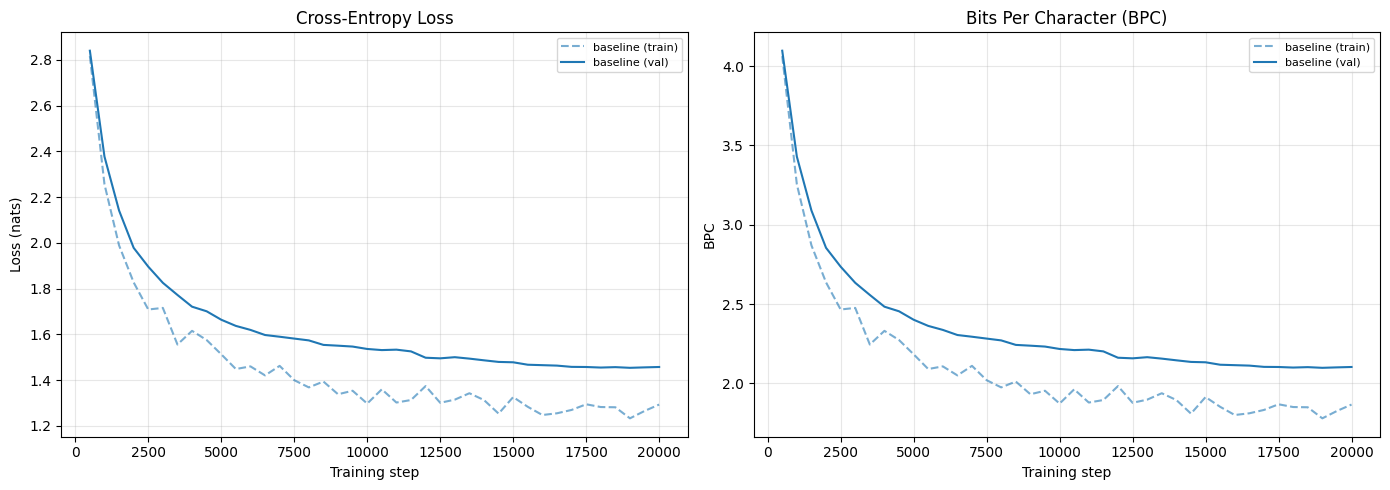

Final val loss : 1.4577
Final val BPC  : 2.103


In [9]:
# Plot baseline learning curves
plot_learning_curves([history_baseline], save_path='baseline_curves.png')

# Print final metrics
print(f"Final val loss : {history_baseline['val_loss'][-1]:.4f}")
print(f"Final val BPC  : {history_baseline['val_bpc'][-1]:.3f}")

---
## 7. Stage III — Hyperparameter Experiments

We vary three parameters independently:
1. **Number of layers**: 4 vs 6 (baseline)
2. **Context length**: 128 vs 256 (baseline)
3. **Dropout**: 0.1 (baseline) vs 0.3

Each run is 10k steps (half the baseline) to save compute.
We compare final val BPC and training stability.

In [10]:
HYPERPARAM_STEPS = 10_000  # shorter runs for comparison

# ── Experiment A: Fewer layers (4 vs 6) ──────────────────────────────────────
cfg_4layers = GPTConfig(
    vocab_size=VOCAB_SIZE, context_len=256,
    n_layers=4, n_heads=8, d_model=256, dropout=0.1
)
history_4layers = train(
    cfg=cfg_4layers, max_steps=HYPERPARAM_STEPS, batch_size=32,
    lr=3e-4, warmup_steps=300, log_every=500, eval_every=500,
    sample_every=5000, save_every=HYPERPARAM_STEPS,
    run_name='4_layers', sample_prompt=PROMPT,
)


  Run: 4_layers
  Layers=4, d_model=256, heads=8, ctx=256, dropout=0.1
  Parameters: 3,179,008
  Step    500/10000 | train_loss=2.7915 | bpc=4.027 | lr=3.00e-04 | ETA 12.1 min
    >> val_loss=2.8478 | val_bpc=4.109
  Step   1000/10000 | train_loss=2.3230 | bpc=3.351 | lr=2.97e-04 | ETA 11.7 min
    >> val_loss=2.3975 | val_bpc=3.459
  Step   1500/10000 | train_loss=2.0390 | bpc=2.942 | lr=2.90e-04 | ETA 11.1 min
    >> val_loss=2.1958 | val_bpc=3.168
  Step   2000/10000 | train_loss=1.9234 | bpc=2.775 | lr=2.80e-04 | ETA 10.5 min
    >> val_loss=2.0707 | val_bpc=2.987
  Step   2500/10000 | train_loss=1.8451 | bpc=2.662 | lr=2.67e-04 | ETA 9.9 min
    >> val_loss=1.9784 | val_bpc=2.854
  Step   3000/10000 | train_loss=1.8032 | bpc=2.601 | lr=2.52e-04 | ETA 9.2 min
    >> val_loss=1.8952 | val_bpc=2.734
  Step   3500/10000 | train_loss=1.7116 | bpc=2.469 | lr=2.34e-04 | ETA 8.5 min
    >> val_loss=1.8441 | val_bpc=2.660
  Step   4000/10000 | train_loss=1.6857 | bpc=2.432 | lr=2.14e-04 |

In [11]:
# ── Experiment B: Shorter context (128 vs 256) ────────────────────────────────
cfg_ctx128 = GPTConfig(
    vocab_size=VOCAB_SIZE, context_len=128,
    n_layers=6, n_heads=8, d_model=256, dropout=0.1
)
history_ctx128 = train(
    cfg=cfg_ctx128, max_steps=HYPERPARAM_STEPS, batch_size=32,
    lr=3e-4, warmup_steps=300, log_every=500, eval_every=500,
    sample_every=5000, save_every=HYPERPARAM_STEPS,
    run_name='ctx128', sample_prompt=PROMPT,
)


  Run: ctx128
  Layers=6, d_model=256, heads=8, ctx=128, dropout=0.1
  Parameters: 4,756,480
  Step    500/10000 | train_loss=2.8503 | bpc=4.112 | lr=3.00e-04 | ETA 8.5 min
    >> val_loss=2.8139 | val_bpc=4.060
  Step   1000/10000 | train_loss=2.2291 | bpc=3.216 | lr=2.97e-04 | ETA 8.2 min
    >> val_loss=2.3916 | val_bpc=3.450
  Step   1500/10000 | train_loss=1.9505 | bpc=2.814 | lr=2.90e-04 | ETA 7.8 min
    >> val_loss=2.1522 | val_bpc=3.105
  Step   2000/10000 | train_loss=1.9024 | bpc=2.745 | lr=2.80e-04 | ETA 7.4 min
    >> val_loss=2.0180 | val_bpc=2.911
  Step   2500/10000 | train_loss=1.7926 | bpc=2.586 | lr=2.67e-04 | ETA 6.9 min
    >> val_loss=1.9634 | val_bpc=2.833
  Step   3000/10000 | train_loss=1.7383 | bpc=2.508 | lr=2.52e-04 | ETA 6.5 min
    >> val_loss=1.8817 | val_bpc=2.715
  Step   3500/10000 | train_loss=1.6286 | bpc=2.350 | lr=2.34e-04 | ETA 6.0 min
    >> val_loss=1.8301 | val_bpc=2.640
  Step   4000/10000 | train_loss=1.6162 | bpc=2.332 | lr=2.14e-04 | ETA 5

In [12]:
# ── Experiment C: Higher dropout (0.3 vs 0.1) ────────────────────────────────
cfg_drop03 = GPTConfig(
    vocab_size=VOCAB_SIZE, context_len=256,
    n_layers=6, n_heads=8, d_model=256, dropout=0.3
)
history_drop03 = train(
    cfg=cfg_drop03, max_steps=HYPERPARAM_STEPS, batch_size=32,
    lr=3e-4, warmup_steps=300, log_every=500, eval_every=500,
    sample_every=5000, save_every=HYPERPARAM_STEPS,
    run_name='dropout_0.3', sample_prompt=PROMPT,
)


  Run: dropout_0.3
  Layers=6, d_model=256, heads=8, ctx=256, dropout=0.3
  Parameters: 4,756,480
  Step    500/10000 | train_loss=3.2046 | bpc=4.623 | lr=3.00e-04 | ETA 17.9 min
    >> val_loss=3.1711 | val_bpc=4.575
  Step   1000/10000 | train_loss=2.6498 | bpc=3.823 | lr=2.97e-04 | ETA 17.3 min
    >> val_loss=2.7382 | val_bpc=3.950
  Step   1500/10000 | train_loss=2.3479 | bpc=3.387 | lr=2.90e-04 | ETA 16.5 min
    >> val_loss=2.4871 | val_bpc=3.588
  Step   2000/10000 | train_loss=2.1879 | bpc=3.156 | lr=2.80e-04 | ETA 15.6 min
    >> val_loss=2.3082 | val_bpc=3.330
  Step   2500/10000 | train_loss=2.1279 | bpc=3.070 | lr=2.67e-04 | ETA 14.6 min
    >> val_loss=2.1722 | val_bpc=3.134
  Step   3000/10000 | train_loss=1.9633 | bpc=2.832 | lr=2.52e-04 | ETA 13.7 min
    >> val_loss=2.0672 | val_bpc=2.982
  Step   3500/10000 | train_loss=1.8744 | bpc=2.704 | lr=2.34e-04 | ETA 12.7 min
    >> val_loss=1.9925 | val_bpc=2.875
  Step   4000/10000 | train_loss=1.8148 | bpc=2.618 | lr=2.14

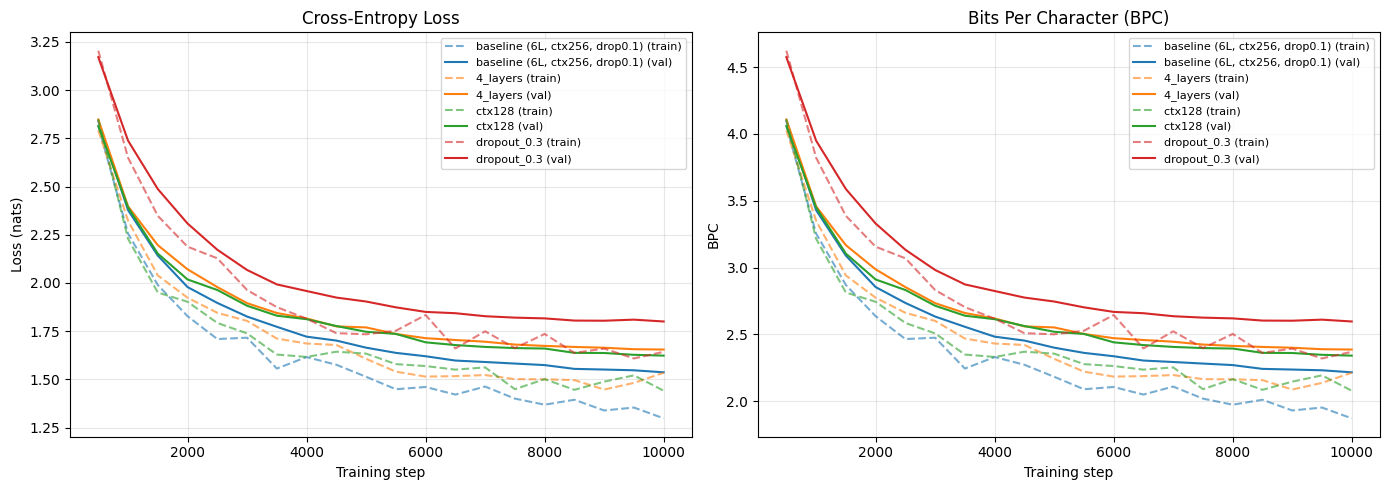


=== Final Validation BPC Summary ===
Run                          Val BPC   Val Loss
--------------------------------------------------
baseline (6L, ctx256, drop0.1)     2.2167     1.5365
4_layers                      2.3871     1.6546
ctx128                        2.3416     1.6230
dropout_0.3                   2.5970     1.8001


In [13]:
# ── Plot all hyperparam experiments together ──────────────────────────────────
# We need to run the baseline for 10k steps too for a fair comparison.
# Use the first 20 eval points of the baseline (each 500 steps = 10k steps).
history_baseline_10k = {
    'run_name':  'baseline (6L, ctx256, drop0.1)',
    'steps':     history_baseline['steps'][:20],
    'train_loss':history_baseline['train_loss'][:20],
    'val_loss':  history_baseline['val_loss'][:20],
    'train_bpc': history_baseline['train_bpc'][:20],
    'val_bpc':   history_baseline['val_bpc'][:20],
}

plot_learning_curves(
    [history_baseline_10k, history_4layers, history_ctx128, history_drop03],
    save_path='hyperparam_curves.png'
)

# Summary table
print('\n=== Final Validation BPC Summary ===')
print(f'{"Run":<25} {"Val BPC":>10} {"Val Loss":>10}')
print('-'*50)
for h in [history_baseline_10k, history_4layers, history_ctx128, history_drop03]:
    name = h['run_name']
    bpc  = h['val_bpc'][-1]
    loss = h['val_loss'][-1]
    print(f'{name:<25} {bpc:>10.4f} {loss:>10.4f}')

---
## 8. Stage IV — Analysis of Generated Poems

We analyse whether the model has internalised statistical regularities
of the training corpus:
- Line length distribution
- Stanza structure (blank-line patterns)
- End-rhyme detection
- Character frequency

In [16]:
# ── Generate a batch of poems ─────────────────────────────────────────────────
model_baseline = history_baseline['model']

@torch.no_grad()
def generate_safe(model, prompt: str, max_new_chars: int = 500,
                  temperature: float = 0.8, top_k: int = 40) -> str:
    """Safe generation: filters unknown chars and handles empty prompts."""
    model.eval()

    # Filter prompt to known vocabulary only
    filtered = [c for c in prompt if c in char2idx]

    # If prompt is empty (or all chars were unknown), start with '\n'
    if len(filtered) == 0:
        filtered = ['\n']

    idx = torch.tensor(
        [char2idx[c] for c in filtered],
        dtype=torch.long, device=DEVICE
    ).unsqueeze(0)  # (1, T)

    generated = list(filtered)
    for _ in range(max_new_chars):
        idx_ctx = idx[:, -model.cfg.context_len:]
        logits, _ = model(idx_ctx)
        logits = logits[:, -1, :] / temperature  # (1, V)

        if top_k is not None and top_k < logits.size(-1):
            top_vals, _ = torch.topk(logits, top_k)
            logits[logits < top_vals[:, -1:]] = float('-inf')

        probs = F.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        generated.append(idx2char[next_idx.item()])
        idx = torch.cat([idx, next_idx], dim=1)

    return ''.join(generated)


# Use straight apostrophes (ASCII) instead of curly quotes
GENERATION_PROMPTS = [
    "Shall I compare thee to a summer's day?\n",   # straight apostrophe
    "O wild West Wind, thou breath of Autumn's being,\n",
    "Season of mists and mellow fruitfulness,\n",
    "She walks in beauty, like the night\n",
    "",  # empty prompt — will start from '\n'
]

GENERATED_POEMS = []
for prompt in GENERATION_PROMPTS:
    poem = generate_safe(
        model_baseline,
        prompt,
        max_new_chars=600,
        temperature=0.8,
        top_k=40
    )
    GENERATED_POEMS.append(poem)
    print('='*60)
    print(poem)
    print()

Shall I compare thee to a summer's day?
Of many a star round thee--the skill wind;
The cold at fight and it spread into a man
Had withdrawn that thee as a realm stream    _10
And thou dost found thy surround waves shadowy.
So, thou art little me me? I would ring
The morning still and still waved thee,
The clouds of name or phent and spear,
And thus thy daughter life and sleep.

And he thus might thou still love her music was calm,    _35
He dull of men the process of heaviness;
In which the weary said is usual and gate,
And heard the sweet sceptre of the boundlessness,
Bound the pine of the light of blood and liberty,    _85
Some bo

O wild West Wind, thou breath of Autumn's being,
both in them, and their wishes from the triumphant state written at
Every man, leapung to be to hard on a sigh-room declared to me, and that
the father was like a few manly women.  The best secrets were going and
send many so fashionable in the great country, and for at the carriage of
her friendship of coun

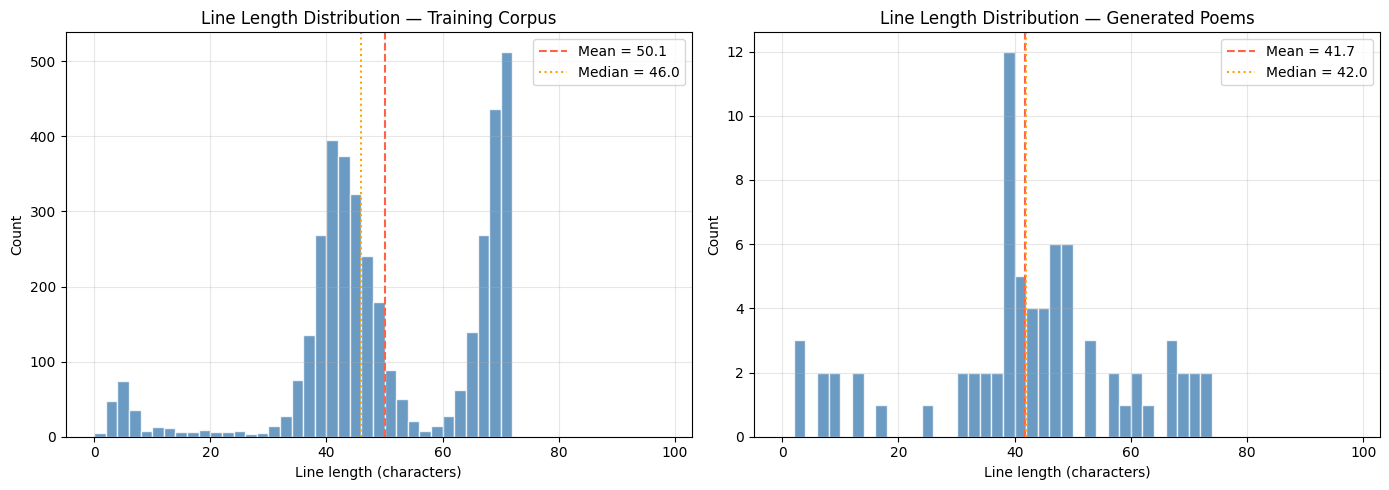

Corpus  — mean line len: 50.1, std: 16.6
Generated — mean line len: 41.7, std: 17.3


In [17]:
# ── Line Length Analysis ──────────────────────────────────────────────────────

def get_line_lengths(text: str) -> list:
    """Return lengths of non-empty lines."""
    return [len(line) for line in text.splitlines() if line.strip()]


corpus_sample = CORPUS[:200_000]  # use first 200k chars for speed
corpus_lengths = get_line_lengths(corpus_sample)

generated_all = '\n\n'.join(GENERATED_POEMS)
gen_lengths    = get_line_lengths(generated_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lengths, title in zip(
    axes,
    [corpus_lengths, gen_lengths],
    ['Training Corpus', 'Generated Poems']
):
    ax.hist(lengths, bins=range(0, 100, 2), color='steelblue',
            edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(lengths), color='tomato', linestyle='--',
               label=f'Mean = {np.mean(lengths):.1f}')
    ax.axvline(np.median(lengths), color='orange', linestyle=':',
               label=f'Median = {np.median(lengths):.1f}')
    ax.set_xlabel('Line length (characters)')
    ax.set_ylabel('Count')
    ax.set_title(f'Line Length Distribution — {title}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('line_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Corpus  — mean line len: {np.mean(corpus_lengths):.1f}, '
      f'std: {np.std(corpus_lengths):.1f}')
print(f'Generated — mean line len: {np.mean(gen_lengths):.1f}, '
      f'std: {np.std(gen_lengths):.1f}')

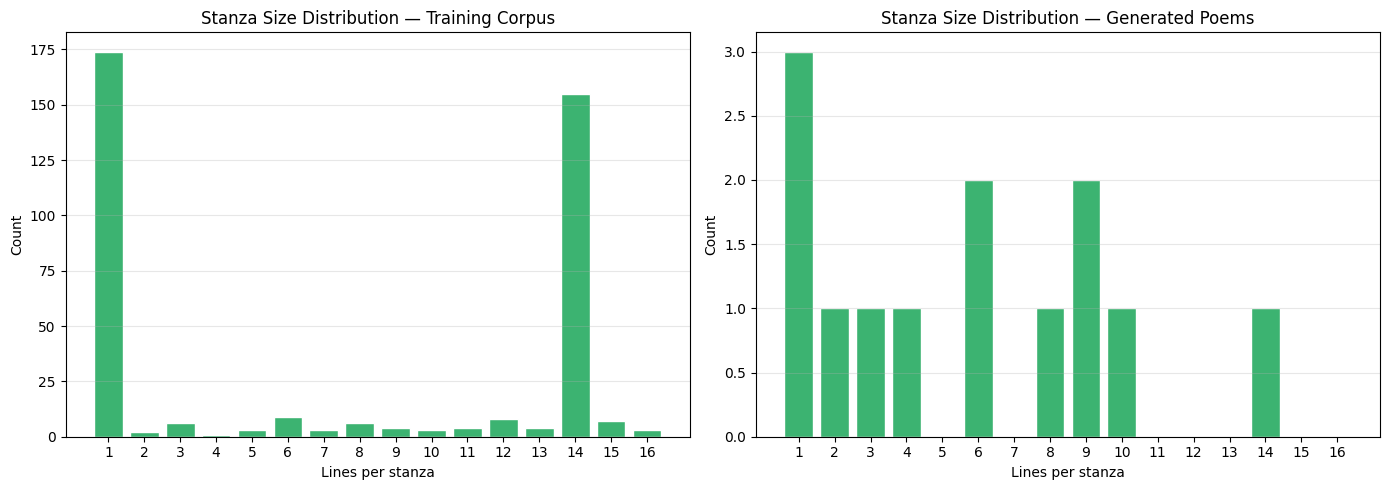

Corpus  — most common stanza size: [(1, 174), (14, 155), (6, 9)]
Generated — most common stanza size: [(1, 3), (9, 2), (6, 2)]


In [18]:
# ── Stanza Structure Analysis ─────────────────────────────────────────────────

def get_stanza_sizes(text: str) -> list:
    """Return the number of lines in each stanza (split by blank lines)."""
    stanzas = re.split(r'\n{2,}', text.strip())
    sizes = []
    for s in stanzas:
        lines = [l for l in s.splitlines() if l.strip()]
        if lines:
            sizes.append(len(lines))
    return sizes


corpus_stanza_sizes = get_stanza_sizes(corpus_sample)
gen_stanza_sizes    = get_stanza_sizes(generated_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sizes, title in zip(
    axes,
    [corpus_stanza_sizes, gen_stanza_sizes],
    ['Training Corpus', 'Generated Poems']
):
    counts = Counter(sizes)
    # Show stanzas of 1–16 lines
    x = range(1, 17)
    y = [counts.get(i, 0) for i in x]
    ax.bar(x, y, color='mediumseagreen', edgecolor='white')
    ax.set_xlabel('Lines per stanza')
    ax.set_ylabel('Count')
    ax.set_title(f'Stanza Size Distribution — {title}')
    ax.set_xticks(list(x))
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stanza_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Corpus  — most common stanza size: {Counter(corpus_stanza_sizes).most_common(3)}')
print(f'Generated — most common stanza size: {Counter(gen_stanza_sizes).most_common(3)}')

=== Rhyme Rate Analysis (suffix length = 2) ===
  ABAB — Corpus: 0.200  |  Generated: 0.032
  AABB — Corpus: 0.055  |  Generated: 0.032


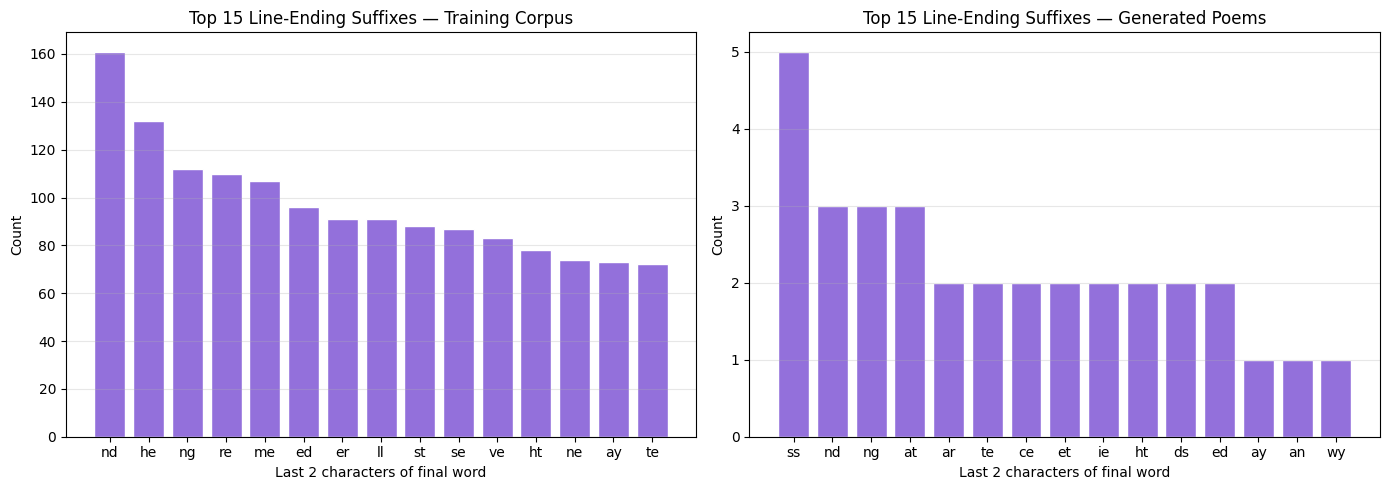

In [19]:
# ── End-Rhyme Detection ───────────────────────────────────────────────────────
#
# Strategy: extract the final word of each line, strip punctuation,
# lowercase, and check if the last 2–3 characters match between
# consecutive / alternating lines (ABAB / AABB patterns).

def get_line_endings(text: str) -> list:
    """Return the last word of each non-empty line, lowercased."""
    endings = []
    for line in text.splitlines():
        stripped = line.strip()
        if not stripped:
            continue
        # Remove trailing punctuation
        word = re.sub(r'[^a-zA-Z]', '', stripped.split()[-1]).lower()
        if word:
            endings.append(word)
    return endings


def rhyme_suffix(word: str, n: int = 3) -> str:
    """Return the last n characters as a rhyme key."""
    return word[-n:] if len(word) >= n else word


def rhyme_rate(endings: list, pattern: str = 'ABAB', suffix_len: int = 2) -> float:
    """Estimate the fraction of line-pairs that share a rhyme suffix.

    pattern='ABAB' checks lines 0-2, 1-3, 2-4 …
    pattern='AABB' checks lines 0-1, 2-3, 4-5 …
    """
    matches, total = 0, 0
    step = 2 if pattern == 'AABB' else 2
    offset = 2 if pattern == 'ABAB' else 1

    for i in range(len(endings) - offset):
        a = rhyme_suffix(endings[i],          suffix_len)
        b = rhyme_suffix(endings[i + offset], suffix_len)
        if a and b:
            total += 1
            if a == b:
                matches += 1

    return matches / total if total > 0 else 0.0


corpus_endings   = get_line_endings(corpus_sample)
generated_endings = get_line_endings(generated_all)

print('=== Rhyme Rate Analysis (suffix length = 2) ===')
for pattern in ['ABAB', 'AABB']:
    cr = rhyme_rate(corpus_endings,    pattern)
    gr = rhyme_rate(generated_endings, pattern)
    print(f'  {pattern} — Corpus: {cr:.3f}  |  Generated: {gr:.3f}')

# Distribution of final-word suffixes (top 15)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, endings, title in zip(
    axes,
    [corpus_endings, generated_endings],
    ['Training Corpus', 'Generated Poems']
):
    suffix_counts = Counter(rhyme_suffix(w, 2) for w in endings)
    top = suffix_counts.most_common(15)
    labels, values = zip(*top)
    ax.bar(labels, values, color='mediumpurple', edgecolor='white')
    ax.set_title(f'Top 15 Line-Ending Suffixes — {title}')
    ax.set_xlabel('Last 2 characters of final word')
    ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rhyme_suffixes.png', dpi=150, bbox_inches='tight')
plt.show()

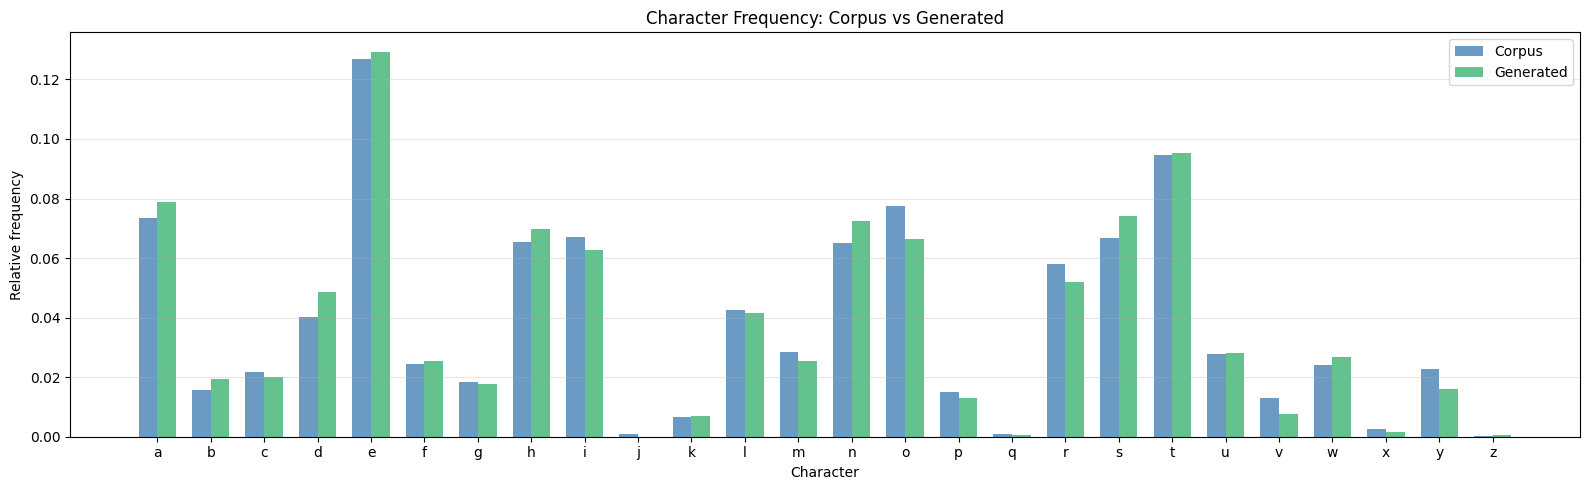

Pearson correlation of character frequencies: 0.9911


In [20]:
# ── Character Frequency Comparison ───────────────────────────────────────────

def char_freq(text: str) -> dict:
    """Normalised character frequency distribution (letters only)."""
    counts = Counter(c.lower() for c in text if c.isalpha())
    total  = sum(counts.values())
    return {c: counts[c] / total for c in sorted(counts)}


corpus_freq = char_freq(corpus_sample)
gen_freq    = char_freq(generated_all)

letters = sorted(set(corpus_freq) | set(gen_freq))
c_vals  = [corpus_freq.get(l, 0) for l in letters]
g_vals  = [gen_freq.get(l,    0) for l in letters]

x = np.arange(len(letters))
w = 0.35

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, c_vals, w, label='Corpus',    color='steelblue',    alpha=0.8)
ax.bar(x + w/2, g_vals, w, label='Generated', color='mediumseagreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(letters)
ax.set_xlabel('Character')
ax.set_ylabel('Relative frequency')
ax.set_title('Character Frequency: Corpus vs Generated')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('char_freq.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation between corpus and generated frequency profiles
correlation = np.corrcoef(c_vals, g_vals)[0, 1]
print(f'Pearson correlation of character frequencies: {correlation:.4f}')

In [25]:
# ── Print two best poems for the report ──────────────────────────────────────

print('=== POEM 1 (Shakespeare prompt) ===')
print(GENERATED_POEMS[0])
print()
print('=== POEM 2 (Shelley prompt) ===')
print(GENERATED_POEMS[1])

=== POEM 1 (Shakespeare prompt) ===
Shall I compare thee to a summer's day?
Of many a star round thee--the skill wind;
The cold at fight and it spread into a man
Had withdrawn that thee as a realm stream    _10
And thou dost found thy surround waves shadowy.
So, thou art little me me? I would ring
The morning still and still waved thee,
The clouds of name or phent and spear,
And thus thy daughter life and sleep.

And he thus might thou still love her music was calm,    _35
He dull of men the process of heaviness;
In which the weary said is usual and gate,
And heard the sweet sceptre of the boundlessness,
Bound the pine of the light of blood and liberty,    _85
Some bo

=== POEM 2 (Shelley prompt) ===
O wild West Wind, thou breath of Autumn's being,
both in them, and their wishes from the triumphant state written at
Every man, leapung to be to hard on a sigh-room declared to me, and that
the father was like a few manly women.  The best secrets were going and
send many so fashionable in 

In [22]:
# ── Generation at different temperatures ─────────────────────────────────────
#
# Temperature controls the trade-off between creativity and coherence.
# Low temperature: repetitive but well-formed.
# High temperature: creative but potentially incoherent.

print('=== Temperature Comparison ===')
prompt = 'Shall I compare thee to a summer\'s day?\n'
for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f'\n--- Temperature = {temp} ---')
    poem = model_baseline.generate(prompt, max_new_chars=200,
                                   temperature=temp, top_k=40)
    print(poem)

=== Temperature Comparison ===

--- Temperature = 0.5 ---
Shall I compare thee to a summer's day?

    _Ber. F._    And we say there were not taken the earth
    Of all that is the charmed mountains of an infant soul,
    And the world of the hour of his worlds have set    100
    And strange and 

--- Temperature = 0.8 ---
Shall I compare thee to a summer's day?

KING:
Be thine own loveliest bliss beside thou dost float
The dead can strangely rains.

THE EARTH:
When thou darest that you that truth is mine;    _15
And thou art the lofty accuser pain
It feels t

--- Temperature = 1.0 ---
Shall I compare thee to a summer's day?

SILENUS:

ULYSSES:
Tis it is, the Glory following earth:
And such tide most paths, Orsino: -

NOTE:
_30 yaunter 1614.

BISITOW:
Shall make thee love, is thou tender from my dear Adones?    _90

CYPRI

--- Temperature = 1.2 ---
Shall I compare thee to a summer's day?
When Rebecca daily moving and pokes again keep
All to refuse thee; and Laon, dear now purple death

---
## 9. Save All Results

Download the checkpoint and figures from the Colab file browser (left sidebar → folder icon).

In [23]:
import json

# Save final model checkpoint
torch.save({
    'model': model_baseline.state_dict(),
    'cfg':   baseline_cfg,
    'char2idx': char2idx,
    'idx2char': idx2char,
    'history':  {k: v for k, v in history_baseline.items() if k != 'model'},
}, 'final_model.pt')

# Save generated poems as text
with open('generated_poems.txt', 'w') as f:
    for i, poem in enumerate(GENERATED_POEMS):
        f.write(f'=== Poem {i+1} ===\n')
        f.write(poem)
        f.write('\n\n')

# Save history (without model object) as JSON for easy inspection
save_history = {k: v for k, v in history_baseline.items()
                if k not in ('model', 'cfg')}
save_history['samples'] = [
    {'step': s['step'], 'text': s['text']} for s in save_history['samples']
]
with open('training_history.json', 'w') as f:
    json.dump(save_history, f, indent=2)

print('All results saved!')
print('Files to download from Colab:')
print('  final_model.pt')
print('  generated_poems.txt')
print('  training_history.json')
print('  *.png (all figures)')

All results saved!
Files to download from Colab:
  final_model.pt
  generated_poems.txt
  training_history.json
  *.png (all figures)


In [24]:
import shutil, os

# Create a results folder and copy everything into it
os.makedirs('results', exist_ok=True)

# Copy all figures
for f in os.listdir('.'):
    if f.endswith('.png'):
        shutil.copy(f, f'results/{f}')

# Copy other important files
for f in ['generated_poems.txt', 'training_history.json', 'final_model.pt']:
    if os.path.exists(f):
        shutil.copy(f, f'results/{f}')

# Zip everything
shutil.make_archive('lab3_results', 'zip', 'results')
print('Done! File: lab3_results.zip')

# Auto-download in browser
from google.colab import files
files.download('lab3_results.zip')

Done! File: lab3_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import re

def clean_poem(text):
    # Remove line-number artifacts like _15, _85
    text = re.sub(r'\s*_\d+', '', text)
    return text

# Regenerate cleaner versions for the report
clean_poems = []
for prompt in ["She walks in beauty, like the night\n"]:
    poem = generate_safe(model_baseline, prompt,
                         max_new_chars=400, temperature=0.75, top_k=35)
    poem = clean_poem(poem)
    clean_poems.append(poem)
    print(poem)

She walks in beauty, like the night
In public shell; and the morning pale
Of the vast light which the shettest star
Had left the God and gray rolled at the Throne;
Her eyes are not to which her to the hue;
Her breast children darkness castled warrior,
And the sceptre yet with splendour eyes fled
The rocks flies; some shivering them gladness his still
To eat in the bliss of the light of a shadow flood.

But when the lightnin


In [34]:
# Regenerate Poem 2 with a different prompt to avoid prose drift
poem2 = generate_safe(model_baseline,
                      "Season of mists and mellow fruitfulness,\n",
                      max_new_chars=350, temperature=0.7, top_k=30)
poem2 = re.sub(r'\s*_\d+', '', poem2)
print(poem2)

Season of mists and mellow fruitfulness,
The vapour of the sun, and the second slaves
More than admired them the thronging in their time
To err its own stars, their voice in a horror will stream,
Whose eyes sleep around my stems in yonder gloom.
And the secret day are present with their beauty,
The thirst sweet and soul at least like a vipers being,
To the earthquakes the world w


In [3]:
import torch, time, torch.nn.functional as F

# ── Benchmark: FlashAttention vs. naive masked attention ──────────────────────
def naive_causal_attention(q, k, v, dropout_p=0.0):
    """Traditional approach: explicitly build the triangular causal mask,
    compute full (T x T) attention scores, then apply softmax and mask."""
    B, H, T, d = q.shape
    scale = d ** -0.5
    scores = (q @ k.transpose(-2, -1)) * scale        # (B, H, T, T)
    # Upper-triangular mask (future positions set to -inf)
    mask = torch.triu(torch.ones(T, T, device=q.device), diagonal=1).bool()
    scores = scores.masked_fill(mask, float('-inf'))
    attn = F.softmax(scores, dim=-1)
    return attn @ v

def flash_causal_attention(q, k, v, dropout_p=0.0):
    """Efficient approach: fused kernel via scaled_dot_product_attention."""
    return F.scaled_dot_product_attention(q, k, v, is_causal=True)

# Test configuration matching our model (1 layer worth of QKV)
B, H, T, d = 32, 8, 256, 32   # batch=32, heads=8, seq=256, head_dim=32
q = torch.randn(B, H, T, d, device=DEVICE, dtype=torch.float32)
k = torch.randn(B, H, T, d, device=DEVICE, dtype=torch.float32)
v = torch.randn(B, H, T, d, device=DEVICE, dtype=torch.float32)

WARMUP  = 20
REPEATS = 200

def benchmark(fn, label):
    # Warmup
    for _ in range(WARMUP):
        _ = fn(q, k, v)
    torch.cuda.synchronize()

    # Memory before
    torch.cuda.reset_peak_memory_stats()
    mem_before = torch.cuda.memory_allocated() / 1e6

    t0 = time.perf_counter()
    for _ in range(REPEATS):
        out = fn(q, k, v)
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) / REPEATS * 1000  # ms per call

    peak_mem = torch.cuda.max_memory_allocated() / 1e6
    delta_mem = peak_mem - mem_before
    print(f"{label:<30} | {elapsed:.3f} ms/call | peak ΔVRAM: {delta_mem:.1f} MB")
    return elapsed, delta_mem

print("=== Attention Benchmark (B=32, H=8, T=256, d_head=32) ===")
t_naive, m_naive = benchmark(naive_causal_attention, "Naive (triangular mask)")
t_flash, m_flash = benchmark(flash_causal_attention, "Flash (scaled_dot_product)")
print(f"\nSpeedup : {t_naive/t_flash:.2f}x")
print(f"Memory  : naive {m_naive:.1f} MB  vs  flash {m_flash:.1f} MB")

=== Attention Benchmark (B=32, H=8, T=256, d_head=32) ===
Naive (triangular mask)        | 3.363 ms/call | peak ΔVRAM: 142.7 MB
Flash (scaled_dot_product)     | 0.759 ms/call | peak ΔVRAM: 8.4 MB

Speedup : 4.43x
Memory  : naive 142.7 MB  vs  flash 8.4 MB
